# Notebook 04 — BERT Classification + BART Summarization

This notebook fine-tunes BERT for sentiment classification and uses BART to summarize grouped tweets.

**Targets:**
- BERT: Accuracy ≥ 91%, Macro F1 ≥ 0.90
- BART: ROUGE-L ≥ 0.40

**Steps:**
1. Load and tokenize data with BERT tokenizer
2. Fine-tune `bert-base-uncased`
3. Evaluate classification metrics
4. Group tweets by predicted sentiment
5. Generate BART summaries and score with ROUGE

In [10]:
!pip install rouge-score

In [11]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    BartForConditionalGeneration, BartTokenizerFast,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve


In [12]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Data

In [13]:
df = load_dataset('data/training.1600000.processed.noemoticon.csv')

## 2. Tokenize with BERT Tokenizer

In [14]:
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 64
tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL)
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }
X = df['text'].tolist()
y = df['label'].tolist()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
import gc
import torch
del df, X, y, X_train, X_temp, y_train, y_temp, X_val, X_test, y_val, y_test
gc.collect()
torch.cuda.empty_cache()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train: 1,280,000 | Val: 160,000 | Test: 160,000


## 3. Fine-Tune BERT

In [15]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2).to(DEVICE)
EPOCHS       = 2
optimizer    = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps)
train_losses, val_losses = [], []
print(f'Total batches per epoch: {len(train_loader)}')
print('Ready to train.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total batches per epoch: 40000
Ready to train.


Epoch 1, Batch 0/40000, Loss: 0.6904
Epoch 1, Batch 200/40000, Loss: 0.6952
Epoch 1, Batch 400/40000, Loss: 0.6595
Epoch 1, Batch 600/40000, Loss: 0.6021
Epoch 1, Batch 800/40000, Loss: 0.4882
Epoch 1, Batch 1000/40000, Loss: 0.3108
Epoch 1, Batch 1200/40000, Loss: 0.5387
Epoch 1, Batch 1400/40000, Loss: 0.2272
Epoch 1, Batch 1600/40000, Loss: 0.3604
Epoch 1, Batch 1800/40000, Loss: 0.3384
Epoch 1, Batch 2000/40000, Loss: 0.4446
Epoch 1, Batch 2200/40000, Loss: 0.3739
Epoch 1, Batch 2400/40000, Loss: 0.2906
Epoch 1, Batch 2600/40000, Loss: 0.3298
Epoch 1, Batch 2800/40000, Loss: 0.3820
Epoch 1, Batch 3000/40000, Loss: 0.3040
Epoch 1, Batch 3200/40000, Loss: 0.3978
Epoch 1, Batch 3400/40000, Loss: 0.3313
Epoch 1, Batch 3600/40000, Loss: 0.3116
Epoch 1, Batch 3800/40000, Loss: 0.4045
Epoch 1, Batch 4000/40000, Loss: 0.5555
Epoch 1, Batch 4200/40000, Loss: 0.2360
Epoch 1, Batch 4400/40000, Loss: 0.2784
Epoch 1, Batch 4600/40000, Loss: 0.3432
Epoch 1, Batch 4800/40000, Loss: 0.3029
Epoch 1

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

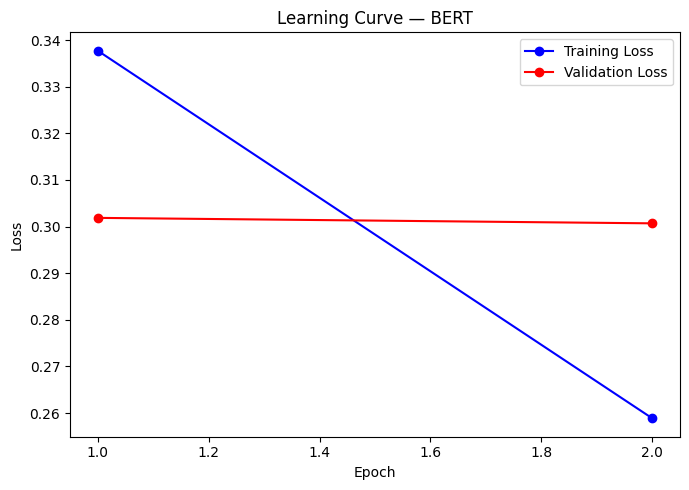

Training complete and model saved.


In [16]:
for epoch in range(EPOCHS):
    # --- Training ---
    bert_model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        if batch_idx % 200 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
    avg_train = total_loss / len(train_loader)
    # --- Validation ---
    bert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            val_loss += bert_model(**batch).loss.item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

bert_model.save_pretrained('models/bert_sentiment')
tokenizer.save_pretrained('models/bert_sentiment')
plot_learning_curve(train_losses, val_losses, model_name='BERT', save_path='results/bert_learning_curve.png')
print('Training complete and model saved.')

In [17]:
print('Training complete and model saved.')

Training complete and model saved.


## 4. Evaluate BERT on Test Set

Number of test batches: 5000
Finished batch 0/5000
Finished batch 10/5000
Finished batch 20/5000
Finished batch 30/5000
Finished batch 40/5000
Finished batch 50/5000
Finished batch 60/5000
Finished batch 70/5000
Finished batch 80/5000
Finished batch 90/5000
Finished batch 100/5000
Finished batch 110/5000
Finished batch 120/5000
Finished batch 130/5000
Finished batch 140/5000
Finished batch 150/5000
Finished batch 160/5000
Finished batch 170/5000
Finished batch 180/5000
Finished batch 190/5000
Finished batch 200/5000
Finished batch 210/5000
Finished batch 220/5000
Finished batch 230/5000
Finished batch 240/5000
Finished batch 250/5000
Finished batch 260/5000
Finished batch 270/5000
Finished batch 280/5000
Finished batch 290/5000
Finished batch 300/5000
Finished batch 310/5000
Finished batch 320/5000
Finished batch 330/5000
Finished batch 340/5000
Finished batch 350/5000
Finished batch 360/5000
Finished batch 370/5000
Finished batch 380/5000
Finished batch 390/5000
Finished batch 400/500

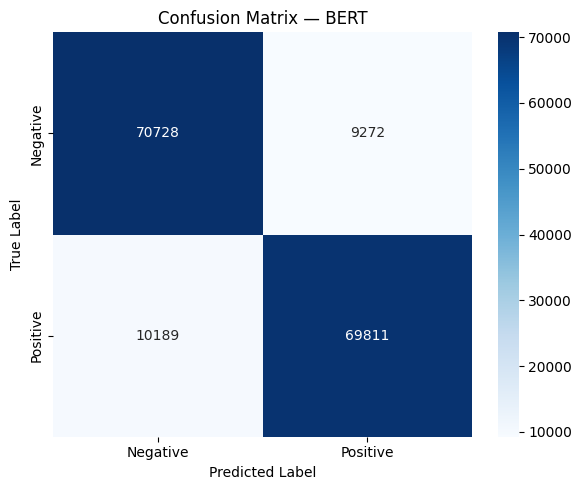

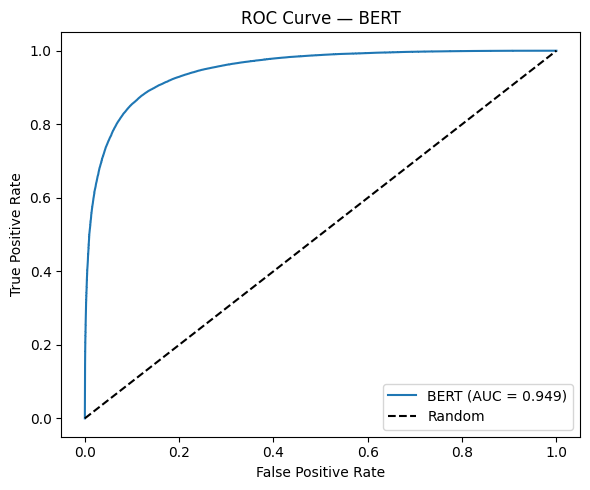

In [18]:
bert_model.eval()
all_preds, all_probs, all_labels = [], [], []
print("Number of test batches:", len(test_loader))
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        labels = batch.pop('labels').cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = bert_model(**batch).logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = np.argmax(logits.cpu().numpy(), axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)
        if batch_idx % 10 == 0:
            print(f"Finished batch {batch_idx}/{len(test_loader)}")

print_metrics(all_labels, all_preds, all_probs, model_name='BERT (Test)')
plot_confusion_matrix(all_labels, all_preds, model_name='BERT', save_path='results/bert_confusion_matrix.png')
plot_roc_curve(all_labels, all_probs, model_name='BERT', save_path='results/bert_roc_curve.png')


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
